# 2 · Simulating Photon Statistics — Lecture with Live Demo

**Lecture · Monday July 27, 14:00–15:00 · live coding — no laptop needed**

We now build every state from this morning's lecture in code, "measure" it with a simulated photon counter, and destroy its quantumness with optical loss — live on screen. Your job in the room: **predict each outcome before the cell runs.** The only thing to do tonight is the 20-minute setup notebook ([`00_Setup_GitHub_Codespaces`](00_Setup_GitHub_Codespaces.ipynb)) so you can participate tomorrow; the exercises below are yours to redo **whenever you find time — this week or after the school**.

### Learning objectives

1. build coherent / thermal / Fock states in **QuTiP** and extract $P(n)$, $\langle n\rangle$, $(\Delta n)^2$,
2. Monte-Carlo-sample detector clicks from a photon number distribution and estimate statistics *from data*,
3. show numerically what **loss** does to sub-Poissonian light.

### How this notebook works

In the session the exercises are live demos — guess each outcome before it runs. **On your own (no deadline)** the cells marked `# YOUR CODE HERE` are yours: each exercise has a ✅ *self-check* cell right after it, and sample solutions are at the very bottom — **try first, peek later.**

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(2026)
print("qutip", qutip.__version__, "- ready")

# Crisp plots on projectors and HiDPI screens (works on Colab too).
%config InlineBackend.figure_format = "retina"

qutip 5.3.0 - ready


## Warm-up (worked example): states and $P(n)$ in QuTiP

QuTiP represents a field mode in a **truncated** Fock space of dimension `N` — always check that your states fit well below the cutoff (rule of thumb: `N > nbar + 5*sqrt(nbar)`).

Three constructors do everything we need today:

```python
qutip.fock(N, n)             # Fock state |n>            (a ket)
qutip.coherent(N, alpha)     # coherent state |alpha>    (a ket)
qutip.thermal_dm(N, nbar)    # thermal state              (a density matrix!)
```

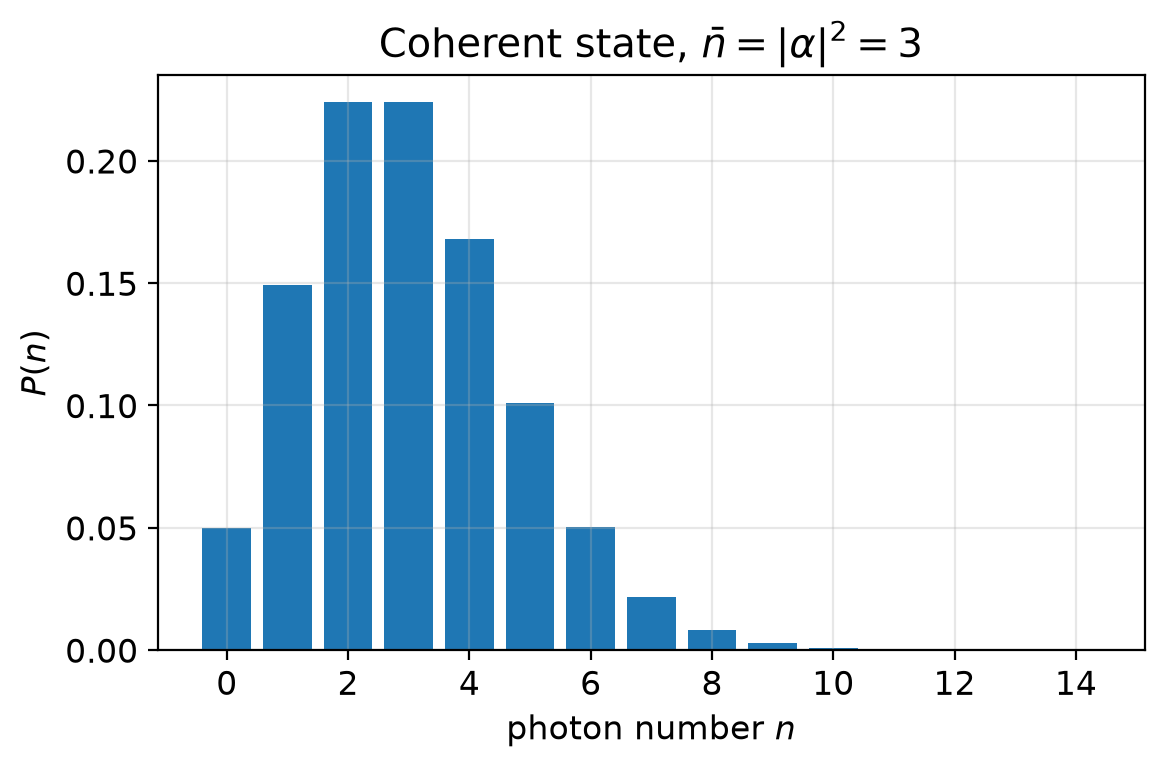

check: <n> = 3.0  (expected 3.0)


In [2]:
N = 100  # Fock-space cutoff. Thermal tails are long: too small a cutoff
         # biases the variance downward (try N = 30 and watch Q shrink!)

def photon_number_distribution(state) -> np.ndarray:
    """P(n) for a single-mode state (ket or density matrix).

    The photon number distribution is the diagonal of the density
    matrix in the Fock basis: P(n) = <n| rho |n>.
    """
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())

# Example: a coherent state with nbar = 3  ->  alpha = sqrt(3)
alpha = np.sqrt(3.0)
psi = qutip.coherent(N, alpha)
P = photon_number_distribution(psi)

plt.bar(np.arange(15), P[:15], color="tab:blue")
plt.xlabel("photon number $n$")
plt.ylabel("$P(n)$")
plt.title(r"Coherent state, $\bar{n} = |\alpha|^2 = 3$")
plt.tight_layout()
plt.show()

print("check: <n> =", np.sum(np.arange(N) * P).round(4), " (expected 3.0)")

## Exercise 1 · The fingerprint figure

Recreate the central figure of Lecture 1: $P(n)$ for a **Fock**, a **coherent**, and a **thermal** state, *all with* $\bar n = 5$, in one plot (bars or steps, your choice — label everything).

*New physics to notice while you plot:* at $\bar n = 5$, what is the single most likely photon number for the thermal state?

In [3]:
# YOUR CODE HERE - Exercise 1
nbar = 5

# build the three states:
# psi_fock = ...
# psi_coh = ...
# rho_th = ...

# plot their photon number distributions in one figure


In [4]:
# ✅ self-check for Exercise 1 (run after your solution)
try:
    for name, st in [("Fock", psi_fock), ("coherent", psi_coh),
                     ("thermal", rho_th)]:
        P = photon_number_distribution(st)
        mean = np.sum(np.arange(len(P)) * P)
        assert abs(mean - 5) < 0.05, f"{name}: <n> = {mean:.2f}, expected 5"
    assert photon_number_distribution(rho_th)[0] > \
           photon_number_distribution(rho_th)[1], \
           "thermal P(0) should exceed P(1) - always!"
    print("Exercise 1 looks correct: all three states have <n> = 5,")
    print("and yes - for thermal light n=0 is STILL the most likely outcome.")
except NameError:
    print("(not solved yet - define psi_fock, psi_coh, rho_th above)")

(not solved yet - define psi_fock, psi_coh, rho_th above)


## Exercise 2 · A `mandel_Q` function

Write the function below and test it. Reminder from the lecture:

$$Q = \frac{(\Delta n)^2 - \bar n}{\bar n},\qquad (\Delta n)^2 = \langle \hat n^2\rangle - \langle \hat n\rangle^2 .$$

Useful QuTiP bits: `qutip.num(N)` is $\hat n$; `qutip.expect(op, state)` works for kets *and* density matrices; operators square with `**2`.

Expected values: coherent $\to 0$, thermal $\to \bar n$, Fock $\to -1$.

In [5]:
def mandel_Q(state) -> float:
    """Mandel Q parameter: (variance - mean)/mean of the photon number.

    Q = 0 Poissonian | Q < 0 sub-Poissonian (non-classical) | Q > 0 super-P.
    """
    # YOUR CODE HERE - Exercise 2
    raise NotImplementedError

In [6]:
# ✅ self-check for Exercise 2
try:
    q_coh = mandel_Q(qutip.coherent(N, 2.0))
    q_th = mandel_Q(qutip.thermal_dm(N, 4.0))
    q_fock = mandel_Q(qutip.fock(N, 4))
    assert abs(q_coh) < 1e-6, f"coherent: Q = {q_coh}, expected 0"
    assert abs(q_th - 4.0) < 1e-3, f"thermal nbar=4: Q = {q_th}, expected 4"
    assert abs(q_fock + 1.0) < 1e-9, f"Fock: Q = {q_fock}, expected -1"
    print(f"Exercise 2 correct:  Q_coh = {q_coh:+.4f}, "
          f"Q_th = {q_th:+.4f}, Q_fock = {q_fock:+.4f}")
except NotImplementedError:
    print("(not solved yet - implement mandel_Q above)")

(not solved yet - implement mandel_Q above)


## Exercise 3 · Statistics of estimating statistics

Real experiments don't hand you $P(n)$ — they hand you a **finite number of measurements**. Simulate a photon-counting experiment:

1. draw `n_shots = 10_000` photon-number samples from the $P(n)$ of each of your three states (`rng.choice(np.arange(N), size=n_shots, p=P)` does this),
2. estimate $\bar n$, $(\Delta n)^2$ and $Q$ **from the samples** (`np.mean`, `np.var`),
3. compare with the exact values from Exercise 2.

*Question to discuss with your neighbor:* repeat with `n_shots = 100`. How reliably can you still certify $Q<0$ for the Fock state? What does that mean for a real experiment with limited measurement time?

**Error bars (do this — every claim needs one):** estimate the uncertainty of your $Q$ by the **bootstrap**: resample your `samples` array with replacement (`rng.choice(samples, size=samples.size)`), recompute $Q$, repeat ~200 times, and quote the standard deviation of the 200 values. For which `n_shots` does the Fock state's $Q + 2\sigma_Q$ stay below 0 — i.e. when is non-classicality certified at ~95% confidence?

In [7]:
# YOUR CODE HERE - Exercise 3
n_shots = 10_000

# for each state: samples = rng.choice(np.arange(N), size=n_shots, p=P)
#                 Q_est   = (np.var(samples) - np.mean(samples)) / np.mean(samples)


## Stretch exercise · Loss eats quantumness

Optical loss (transmission $\eta$) acts on photons like a biased coin: each photon survives independently with probability $\eta$. On the level of $P(n)$ this is a **binomial thinning**:

$$P_\eta(m) \;=\; \sum_{n\ge m} P(n)\,\binom{n}{m}\,\eta^m (1-\eta)^{n-m}.$$

(The same result comes from a beamsplitter model where the lost photons exit the unused port — Wednesday we build exactly that in Perceval.)

**Task:** starting from the Fock state $|4\rangle$, compute and plot $Q$ after loss as a function of $\eta \in [0, 1]$ (use the binomial-thinning formula on $P(n)$, then your Q from moments of the thinned distribution — no QuTiP needed here).

You should find $Q(\eta) = -\eta$: the state stays sub-Poissonian for *any* $\eta > 0$…but barely. This is the daily life of single-photon experiments: **efficiency is everything.**

*Open-systems note:* if you know the Lindblad equation, binomial thinning **is** the photon-loss channel — the fixed-time solution of $\dot\rho = \gamma\,\mathcal{D}[\hat a]\rho$ with $\eta = e^{-\gamma t}$, a.k.a. the amplitude-damping channel. Beamsplitter picture and master-equation picture: same physics, two notations.

In [8]:
# YOUR CODE HERE - Stretch exercise
from scipy.stats import binom

eta_axis = np.linspace(0, 1, 21)

# P4 = photon_number_distribution(qutip.fock(N, 4))
# for each eta: thin P4, compute mean & var of the thinned distribution, get Q
# plot Q vs eta; overlay the prediction Q = -eta


## Exercise 4 · See the states: Wigner functions

The lecture's phase-space triptych, but yours. Plot the Wigner function (`qutip.wigner(state, xvec, xvec)` on `xvec = np.linspace(-6, 6, 201)`) for:

1. the vacuum $|0\rangle$ and the Fock state $|1\rangle$,
2. your coherent and thermal states from Exercise 1,
3. *(from the lecture's LIGO section)* the squeezed vacuum `qutip.squeeze(N, 0.7) * qutip.fock(N, 0)`.

For each: is it negative anywhere? Print the minimum value. Then compute $\Delta X$ and $\Delta P$ for each state (`qutip.variance(qutip.position(N), state)` etc.) and compare with the vacuum value $1/\sqrt2$: **which states beat vacuum noise in some quadrature — and is the Fock state among them?** (It is not: its rings sit *outside* the vacuum disk in every direction — Lecture 1's misconception box, now in your own numbers.) Which of your states are certified non-classical by Wigner negativity, and which by $Q < 0$ — and is it the *same* set? (It is not! Squeezed vacuum: $W$-positive-Gaussian yet non-classical by quadrature noise; $|1\rangle$: both witnesses fire. Different witnesses see different quantumness.)

In [9]:
# YOUR CODE HERE - Exercise 4
xvec = np.linspace(-6, 6, 201)


## Demo · The classic trap: "a Fock state is squeezed, right?"

You have just plotted Wigner functions — the perfect moment for the misconception this morning's lecture left dangling.

A persistent misconception, worth killing with numbers: because Fock states are exotic and squeezed states are exotic, the two get conflated — *"a Fock state is a squeezed state"*. It is not. **Squeezed** means: noise in *some* quadrature **below the vacuum level** $\Delta X_{\rm vac} = 1/\sqrt2$. Compute the quadrature noise of every state we met today:

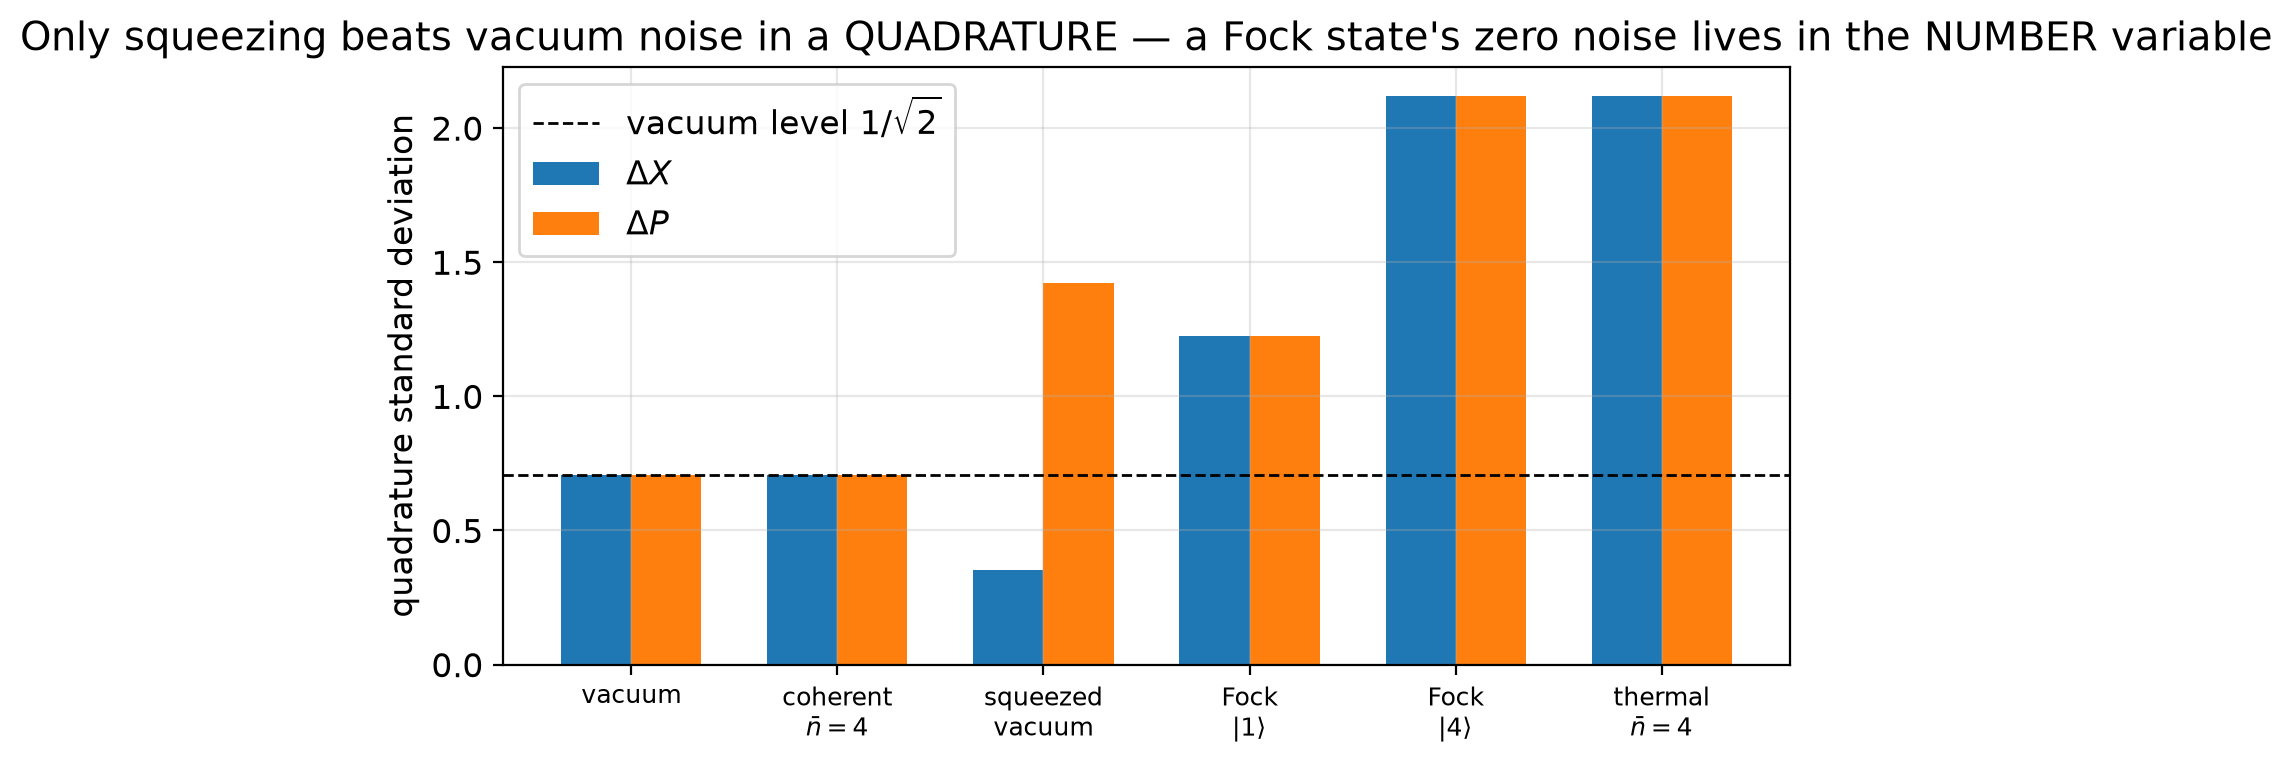

Fock |4>: dX = dP = 2.121 - identical to thermal nbar=4 (2.121)!


In [10]:
# Is anything here actually squeezed? Quadrature noise vs the vacuum level.
states_q = [("vacuum", qutip.fock(N, 0)),
            ("coherent\n" + r"$\bar{n}=4$", qutip.coherent(N, 2.0)),
            ("squeezed\nvacuum", qutip.squeeze(N, 0.7) * qutip.fock(N, 0)),
            ("Fock\n" + r"$|1\rangle$", qutip.fock(N, 1)),
            ("Fock\n" + r"$|4\rangle$", qutip.fock(N, 4)),
            ("thermal\n" + r"$\bar{n}=4$", qutip.thermal_dm(N, 4.0))]

x_op, p_op = qutip.position(N), qutip.momentum(N)
dX = [np.sqrt(qutip.variance(x_op, st)) for _, st in states_q]
dP = [np.sqrt(qutip.variance(p_op, st)) for _, st in states_q]

xpos = np.arange(len(states_q))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(xpos - 0.17, dX, 0.34, label=r"$\Delta X$", color="tab:blue")
ax.bar(xpos + 0.17, dP, 0.34, label=r"$\Delta P$", color="tab:orange")
ax.axhline(1 / np.sqrt(2), color="k", ls="--", lw=1,
           label=r"vacuum level $1/\sqrt{2}$")
ax.set_xticks(xpos, [n for n, _ in states_q], fontsize=9)
ax.set_ylabel("quadrature standard deviation")
ax.set_title("Only squeezing beats vacuum noise in a QUADRATURE — "
             "a Fock state's zero noise lives in the NUMBER variable")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fock |4>: dX = dP = {dX[4]:.3f} - identical to thermal nbar=4"
      f" ({dX[5]:.3f})!")

Read the bars:

* only the **squeezed vacuum** dips below the dashed vacuum line — in one quadrature, paying for it in the other;
* **Fock states sit *above* vacuum noise in every quadrature**, $\Delta X = \Delta P = \sqrt{n + \tfrac12}$ — their Wigner rings lie *outside* the vacuum disk in all directions, with no preferred axis to squeeze along (a state of definite $n$ has no phase — this morning's §1.4!). Their zero noise is real but lives in the *number* variable, $\Delta n = 0$ — a resource for counting-type measurements, invisible to any quadrature/phase readout;
* the punchline: $|4\rangle$ and the *thermal* state with $\bar n = 4$ have **identical quadrature noise** — second moments cannot tell our most quantum state from our most classical one.

So the two flagship non-classical states are non-classical in *orthogonal* ways:

| state | quadrature noise vs vacuum | Gaussian? | Wigner | non-classicality witness |
|---|---|---|---|---|
| coherent | equal | yes | positive | — (the classical reference) |
| thermal | above | yes | positive | — |
| **squeezed vacuum** | **below** (one axis) | yes | positive | sub-vacuum noise (2nd moments) |
| **Fock** | above (all axes) | **no** | **negative** | Wigner negativity (beyond 2nd moments) |

Squeezing lives entirely in second moments, so a **homodyne** measurement sees it (that is LIGO's detection chain). Fock-state quantumness is invisible to second moments — you need **photon counting** to see it. Two different windows into the quantum world; this course looks through the second one.

### The natural next question: why doesn't LIGO just use Fock states?

$\Delta n = 0$, $Q = -1$ — *no photon-number noise at all.* Shouldn't a Fock state be the ultimate interferometer fuel? Look at $|0\rangle, |1\rangle, |2\rangle$ in phase space before answering:

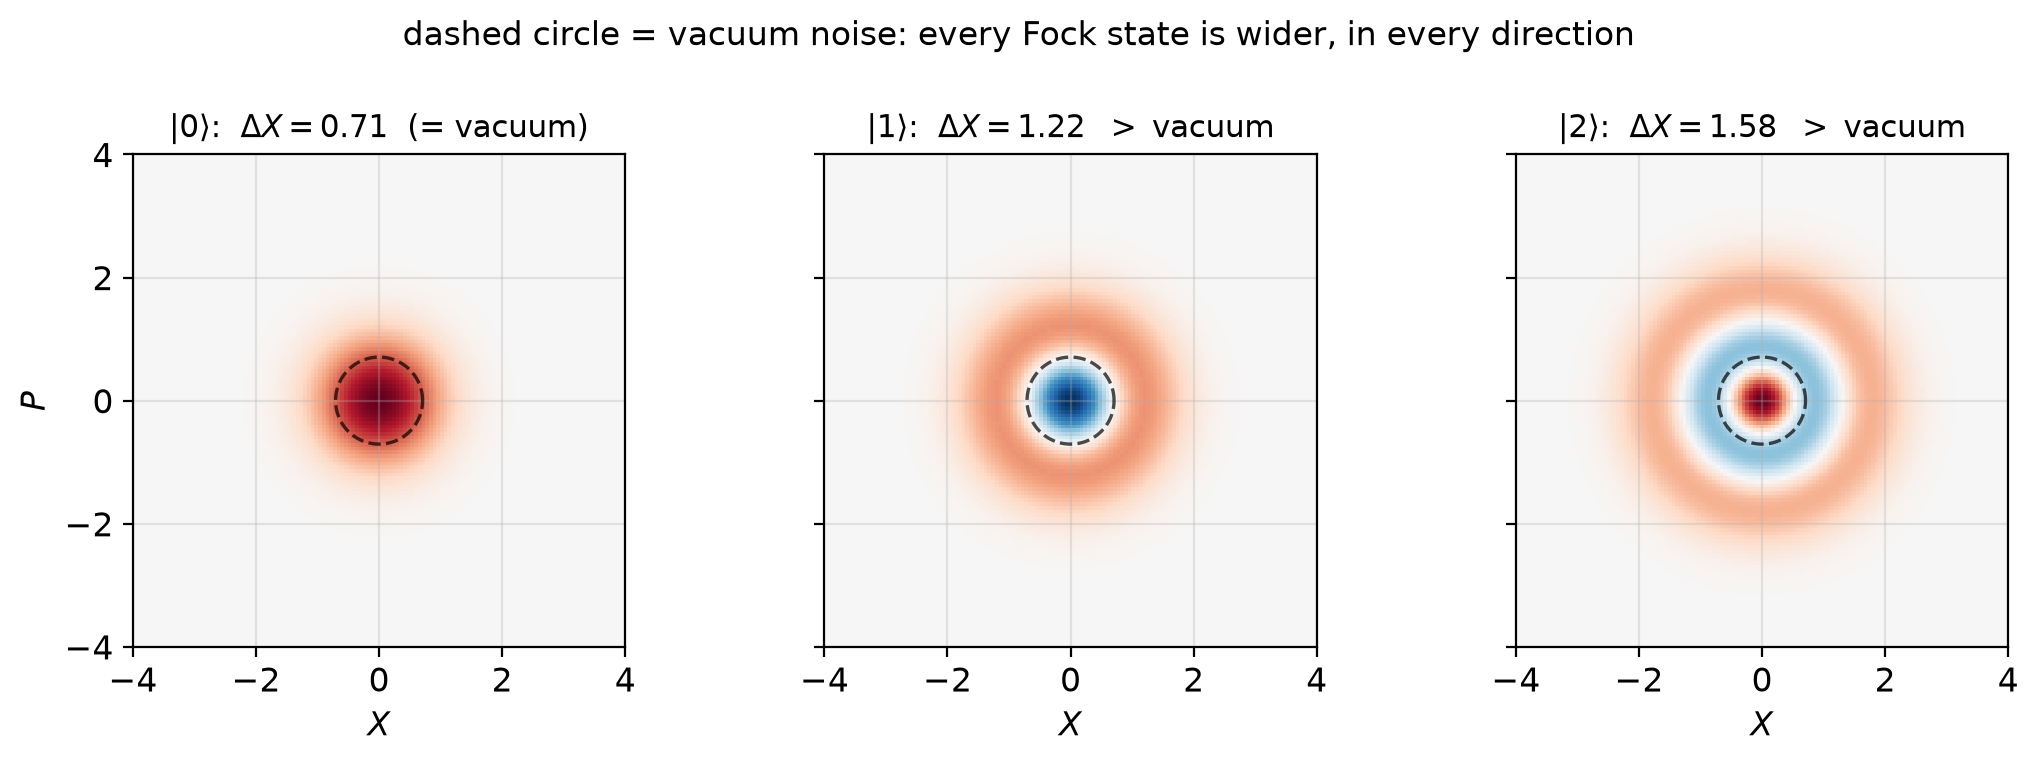

In [11]:
# The dark-port candidates: |0>, |1>, |2> in phase space.
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
vac_r = 1 / np.sqrt(2)
for ax, n_f in zip(axes, [0, 1, 2]):
    st = qutip.fock(N, n_f)
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    # dashed circle: the vacuum quadrature width, for comparison
    th = np.linspace(0, 2 * np.pi, 100)
    ax.plot(vac_r * np.cos(th), vac_r * np.sin(th), "--", color="k",
            lw=1.2, alpha=0.7)
    dX = np.sqrt(qutip.variance(qutip.position(N), st))
    ax.set_title(rf"$|{n_f}\rangle$:  $\Delta X = {dX:.2f}$"
                 + ("  (= vacuum)" if n_f == 0 else "  $>$ vacuum"),
                 fontsize=11)
    ax.set_xlabel("$X$")
    ax.set_aspect("equal")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
axes[0].set_ylabel("$P$")
fig.suptitle("dashed circle = vacuum noise: every Fock state is wider, "
             "in every direction", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

Now the answers, one candidate at a time:

* **"Inject $|0\rangle$ into the dark port"** — congratulations, that is the *status quo*. The "empty" port is never empty: it already contains the vacuum state, and its $\Delta X = 1/\sqrt2$ fuzz **is** the shot noise (Caves' whole point). Mixing in more vacuum changes nothing.
* **"Inject $|1\rangle$ or $|2\rangle$"** — look at the rings: wider than the dashed vacuum circle in *every* direction ($\Delta X = \sqrt{n + \tfrac12}$). Injecting a Fock state makes the interferometer **noisier**. The readout is a *phase* measurement, and $\Delta n = 0$ is certainty in the wrong variable — number-definite states are exactly the ones with *no* phase. Shot noise in a fringe is *quadrature* noise, not photon-number noise; only a state with sub-vacuum noise in the measured quadrature helps, and rotationally symmetric states cannot have one. **Helping requires breaking the symmetry — that is what squeezing is.**
* **"Then run the whole interferometer on Fock light"** — this one is *almost* right, and Wednesday you will build it: interfering number states (the NOON state of Lab 5) picks up phase $N$ times faster, reaching the **Heisenberg limit** $1/N$ instead of shot noise's $1/\sqrt{N}$. The catch is subtler than "you can't make $10^{22}$" — that would be a strawman, because the *point* of Heisenberg scaling $1/N$ is that you would need far fewer photons: $N \sim 10^{11}$ would match LIGO's $10^{-11}$, eleven orders below what the laser carries. The real catches: (i) the largest number-entangled states ever prepared are $N \approx 5$ (NOON [Afek2010]) to a few tens (cavity Fock states) — still ten orders short; and (ii) number-state interferometry is fragile to loss — one absorbed photon poisons a NOON state, while squeezed light merely *degrades*, and there is a theorem waiting at the end of this notebook that makes the loss point precise. Squeezing is the loss-tolerant way to spend a quantum resource next to 200 kW of classical power. (Quantum advantage in optics is always a fight against loss — Wednesday's heralding lab is the same lesson from the other side.)



## Demo · Why nobody ever noticed (multimode washout)

Objection from the back row: *"Sunlight is thermal and my photodiode integrates sunlight — where is the Bose–Einstein distribution with its wild fluctuations?"*

Resolution: Bose–Einstein statistics hold **per mode**. A real detector integrates over $M$ modes — $M \approx \frac{\text{detection time}}{\text{coherence time}} \times \frac{\text{detection area}}{\text{coherence area}} \times 2$ polarizations. Sunlight has femtosecond coherence: even a 1 ns detector sees $M \sim 10^6$.

Summing $M$ independent thermal modes (total mean $\bar n$) gives the **negative binomial** distribution with

$$Q = \frac{\bar n}{M} \;\xrightarrow{\;M\to\infty\;}\; 0 .$$

The bunching washes out as $1/M$: thermal light *hides* its statistics from slow, fat detectors. (And recall this morning's aside: even per mode, every lab source is only *approximately* thermal — the one emitter nature makes exactly thermal is a black hole [Hawking1975].) This is why nobody stumbled on photon bunching for 50 years — and why its discovery (HBT, 1956, with a narrowband mercury line and fast electronics — tomorrow's opening story) shocked the physics community.

*Quick estimate to discuss:* how many modes $M$ for (a) sunlight on a 100 ps-gated detector of 100 µm diameter, (b) a single-mode-fiber-coupled, 1 nm-filtered source on an SNSPD? For which could you hope to see bunching? — Keep $Q = \bar n/M$ in mind: it returns in Exercise 5 as **ASE**.

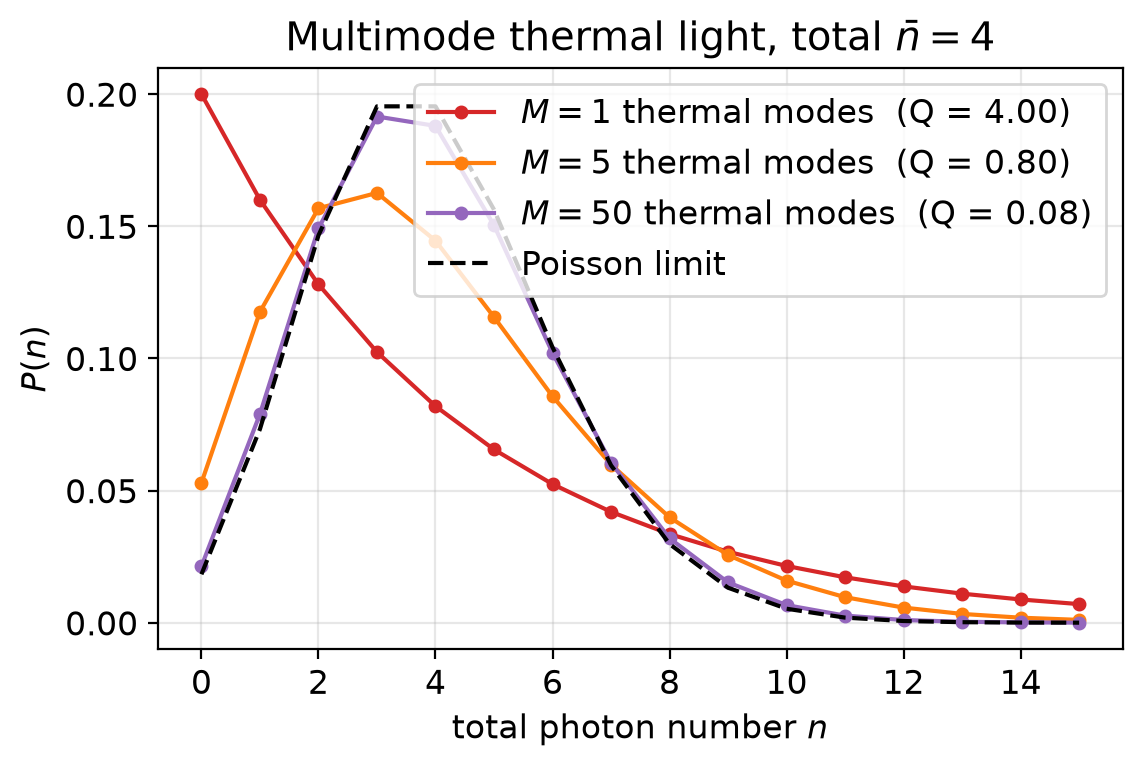

In [12]:
# Multimode thermal light: Bose-Einstein morphs into Poisson as M grows.
from scipy.special import comb, factorial

def negative_binomial_P(n: np.ndarray, nbar: float, M: int) -> np.ndarray:
    """P(n) for M equally bright thermal modes with total mean nbar."""
    x = nbar / M
    return comb(n + M - 1, n) * x**n / (1 + x)**(n + M)

n_axis = np.arange(16)
fig, ax = plt.subplots()
for M, color in [(1, "tab:red"), (5, "tab:orange"), (50, "tab:purple")]:
    ax.plot(n_axis, negative_binomial_P(n_axis, 4.0, M), "o-", ms=4,
            color=color, label=f"$M = {M}$ thermal modes  (Q = {4.0/M:.2f})")
ax.plot(n_axis, np.exp(-4.0) * 4.0**n_axis / factorial(n_axis), "k--",
        label="Poisson limit")
ax.set_xlabel("total photon number $n$")
ax.set_ylabel("$P(n)$")
ax.set_title(r"Multimode thermal light, total $\bar{n} = 4$")
ax.legend()
plt.tight_layout()
plt.show()

## Exercise 5 · A laser near threshold (Arecchi 1965)

Below threshold a laser emits thermal light; far above, coherent light. Near threshold, a decent model is a **mixture**: with probability $p$ the cavity outputs thermal light, with $1-p$ coherent light (same $\bar n = 5$ for both).

1. Build $\rho(p) = (1-p)\,|\alpha\rangle\langle\alpha| + p\,\rho_{\rm th}$ in QuTiP (`qutip.ket2dm` for the coherent part).
2. Plot $Q(p)$ for $p \in [0, 1]$.
3. Arecchi's 1965 photon-counting experiment [Arecchi1965] distinguished laser and lamp light this way — decades before single-photon detectors. From your plot: how small a thermal admixture $p$ is detectable if you can measure $Q$ to $\pm 0.05$?
4. **ASE — the thermal light hiding in every fiber amplifier.** An amplifier without a cavity (EDFA, SOA) emits **amplified spontaneous emission**: thermal statistics spread over $M \gg 1$ spectral–temporal modes, and from Lecture 1, $M$ equally bright thermal modes give $Q = \bar n / M$. Plot $Q(M)$ at total $\bar n = 5$ for $M = 1 \dots 10^4$ (log axis): how strongly must you *filter* the ASE (how small an $M$) before a $\pm 0.05$ measurement tells it from a laser? This is why raw broadband ASE passes for Poissonian light on any real detector — and why revealing its bunching takes a narrow filter *and* fast detection (exactly Tuesday's theme).

In [13]:
# YOUR CODE HERE - Exercise 5
p_values = np.linspace(0, 1, 11)


## Case study · Doing experimental physics better with quantum light

You now own every state in the toolbox — so let's use them on a real problem, the one from this morning: **measure a tiny length change** (LIGO's, or your own cavity's). Classical best effort: a coherent beam with $N$ detected photons gives $\Delta\varphi = 1/\sqrt{N}$, and after that you can only raise the power. Quantum optics offers **three different rulers**, and choosing between them is a masterclass in how quantum advantages live or die in a lab:

**Ruler 1 — keep the laser, squeeze the vacuum** *(the deployed one).* Attack the noise, not the signal: replace the dark-port vacuum with squeezed vacuum and win a **prefactor**, $e^{-r}/\sqrt{N}$ — the scaling stays $1/\sqrt N$ [Tse2019]. It coexists with hundreds of kW of circulating power, and loss merely shortens the win ($r_{\rm eff}$ shrinks; nothing breaks). Kilometer-scale record 6.0 dB [Lough2021]; since 2023, frequency-dependent squeezing delivers both quadratures at once [Ganapathy2023]. *Lesson: the cheapest quantum win is often in the port everyone thought was empty.*

**Ruler 2 — change the scaling** *(the seductive one).* Interfere number states and the phase accumulates $N$ times faster: the Heisenberg limit $1/N$ [Giovannetti2011]. NOON states do it (tomorrow-afternoon's exercise shows the doubled fringe), and you don't even need NOON's fragility — twin-Fock inputs $|N\rangle|N\rangle$ reach the same scaling more robustly [HollandBurnett1993]. Reality check, twice: the experimental record is $N = 5$ [Afek2010]; and the theorem that governs every proposal in this business — with *any* fixed loss, the asymptotic Heisenberg advantage collapses to a **constant factor** over shot noise [Demkowicz2012]. Read that twice: under loss, ruler 2's endgame is *a better prefactor* — which is exactly what ruler 1 already delivers, robustly, at any power. The bound is even quantitative, $\Delta\varphi \ge \sqrt{(1-\eta)/\eta}/\sqrt{N}$, and the paper's own worked example is GEO600: predicted maximal quantum enhancement factor 0.62 at its measured transmission $\eta = 0.62$, observed 0.67 — **the deployed squeezed-light detector already operates within a few percent of the fundamental lossy quantum limit** [Demkowicz2012]. Rulers 1 and 2 meet: squeezing is not just the practical choice, it is nearly all the quantum advantage that loss leaves on the table. *Lesson: scaling claims must survive the loss budget, and usually don't.*

**Ruler 3 — change the observable** *(the sly one).* If phase stability is your enemy, stop measuring phase. Broadband photon pairs lose their first-order fringes within femtoseconds — but the coherence doesn't vanish, it hides in $g^{(2)}$: the **HOM dip visibility** (tomorrow afternoon's lab) is a delay meter of **attosecond** accuracy — average 6 as, best 0.5 as, resolved with photons whose wavepackets are *tens of femtoseconds* long, four orders of magnitude coarser than the delays they measure — that needs *no* phase stabilization, and loss only costs event rate [Lyons2018]. (Their trick: sit at the Fisher-information-optimal point on the dip's *slope*, not its bottom, and let $10^9$ coincidences do the rest.) The fine print is subtler than "wrong observable": in a *medium* (glass, fiber, tissue) group delay and optical phase genuinely differ — but a gravitational wave is **not a medium**. It modulates the light travel time *achromatically* (spacetime is non-dispersive for light), so for a GW, phase delay $\equiv$ group delay [Saulson1997] and a time ruler is a legitimate GW readout in principle. What actually separates HOM timing from LIGO is **carrier gearing and flux**: a phase readout measures $\omega_{\rm opt}\,\delta\tau$ — a $\sim 10^{15}$ multiplier for free — and carries $10^{22}$ photons against MHz pair rates. Yet the counting route is live research: photon-counting readout of GW-band interferometers can beat homodyne for *detecting* weak non-Gaussian signals — the GQuEST experiment is being built on exactly that [GQuEST2025]. *Lesson: sometimes the quantum move is not a better state but a better question — and which question wins can change with the task.*

| ruler | improves | costs / fragility | status |
|---|---|---|---|
| squeezed vacuum | prefactor $e^{-r}$ | loss trims it gracefully | in production at LIGO/Virgo/GEO |
| number states | scaling $1/\sqrt N \to 1/N$ | loss voids the scaling [Demkowicz2012]; $N \le$ few | lab demonstrations |
| HOM visibility | phase stability not needed at all | no carrier gearing — flux-limited (for GWs, phase $\equiv$ group delay [Saulson1997]) | attosecond metrology; GW photon-counting proposals [GQuEST2025] |

The meta-lesson for your own experiments: **"use quantum" is not one strategy.** Ask what limits you — noise floor, scaling, or stability — and pick the resource whose *failure mode you can afford*. Tomorrow you measure the correlations behind ruler 3; Wednesday you build the states behind ruler 2 and watch loss eat them, quantitatively.

---
## If you finish early

* Prove analytically that binomial thinning of a Poisson distribution is again Poisson (this is why attenuated lasers never become quantum).
* Compute $Q$ of the state $\rho = p\,|1\rangle\langle 1| + (1-p)\,|0\rangle\langle 0|$ (question 4 from the lecture) and check numerically.

## Keep it

This notebook — self-checks, stretch goals, and the sample solutions below — stays online after the school. Redo the exercises at your own pace; **nothing needs to be handed in.**

---
---

# Sample solutions

**No peeking during the session** — these are for checking afterwards (and for anyone who got stuck at home).

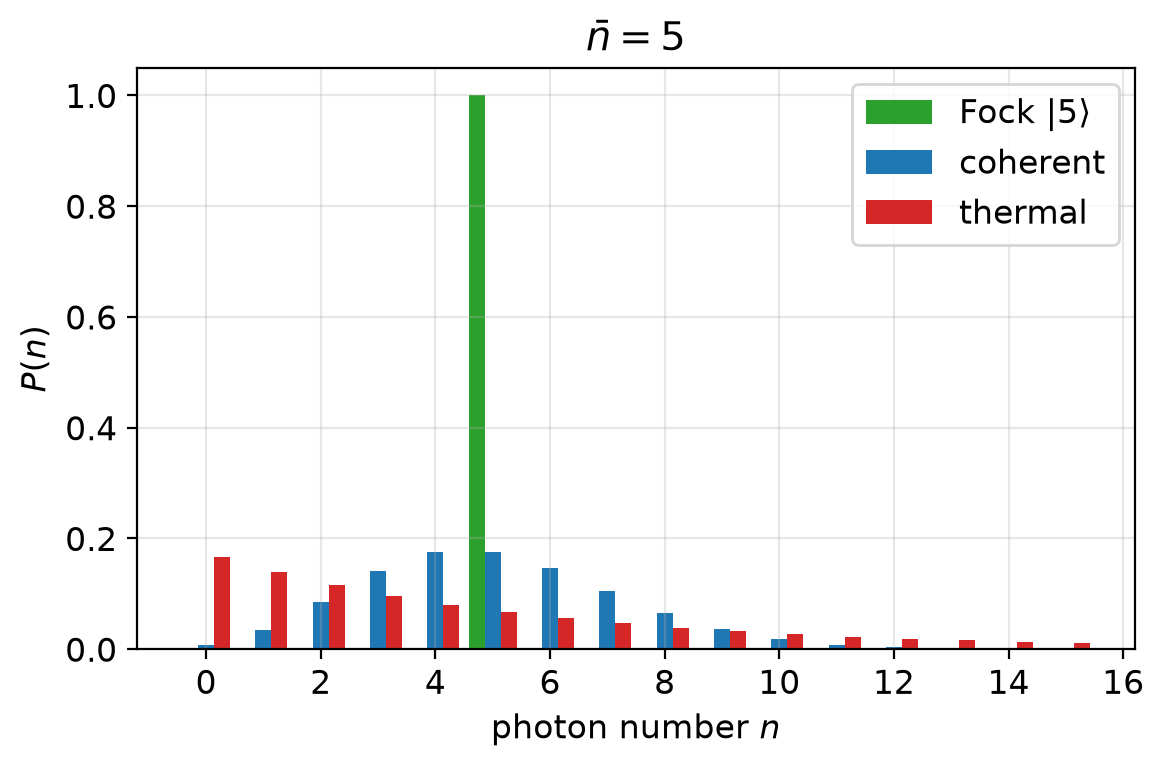

In [14]:
# Solution - Exercise 1
nbar = 5
psi_fock = qutip.fock(N, nbar)
psi_coh = qutip.coherent(N, np.sqrt(nbar))
rho_th = qutip.thermal_dm(N, nbar)

n_axis = np.arange(16)
width = 0.28
fig, ax = plt.subplots()
for i, (label, st, c) in enumerate([("Fock $|5\\rangle$", psi_fock, "tab:green"),
                                    ("coherent", psi_coh, "tab:blue"),
                                    ("thermal", rho_th, "tab:red")]):
    ax.bar(n_axis + (i - 1) * width,
           photon_number_distribution(st)[:len(n_axis)], width,
           label=label, color=c)
ax.set_xlabel("photon number $n$"); ax.set_ylabel("$P(n)$")
ax.set_title(r"$\bar{n} = 5$"); ax.legend(); plt.tight_layout(); plt.show()

In [15]:
# Solution - Exercise 2
def mandel_Q(state) -> float:
    """Mandel Q parameter: (variance - mean)/mean of the photon number."""
    n_op = qutip.num(state.shape[0])
    mean = qutip.expect(n_op, state)
    var = qutip.expect(n_op**2, state) - mean**2
    return (var - mean) / mean

for label, st in [("coherent", psi_coh), ("thermal", rho_th),
                  ("Fock", psi_fock)]:
    print(f"{label:9s} Q = {mandel_Q(st):+.4f}")

coherent  Q = -0.0000
thermal   Q = +5.0000
Fock      Q = -1.0000


In [16]:
# Solution - Exercise 3 (with bootstrap error bars)
def Q_of(samples: np.ndarray) -> float:
    """Sample estimate of the Mandel Q parameter."""
    return (np.var(samples) - np.mean(samples)) / np.mean(samples)

n_shots = 10_000
n_boot = 200
print(f"{'state':<10}{'Q exact':>9}{'Q estimated':>18}")
for label, st in [("coherent", psi_coh), ("thermal", rho_th),
                  ("Fock", psi_fock)]:
    P = photon_number_distribution(st)
    P = P / P.sum()                       # numerical safety renormalization
    samples = rng.choice(np.arange(N), size=n_shots, p=P)
    # bootstrap: resample the *measured data* with replacement
    q_boot = [Q_of(rng.choice(samples, size=samples.size))
              for _ in range(n_boot)]
    print(f"{label:<10}{mandel_Q(st):>+9.3f}"
          f"{Q_of(samples):>+12.3f} ± {np.std(q_boot):.3f}")
# With n_shots = 100 the Fock-state error bar grows to ~0.1-0.2 and
# Q + 2*sigma can cross zero: certifying non-classicality takes statistics,
# not one lucky run.

state       Q exact       Q estimated
coherent     -0.000      -0.005 ± 0.014
thermal      +5.000      +5.017 ± 0.121
Fock         -1.000      -1.000 ± 0.000


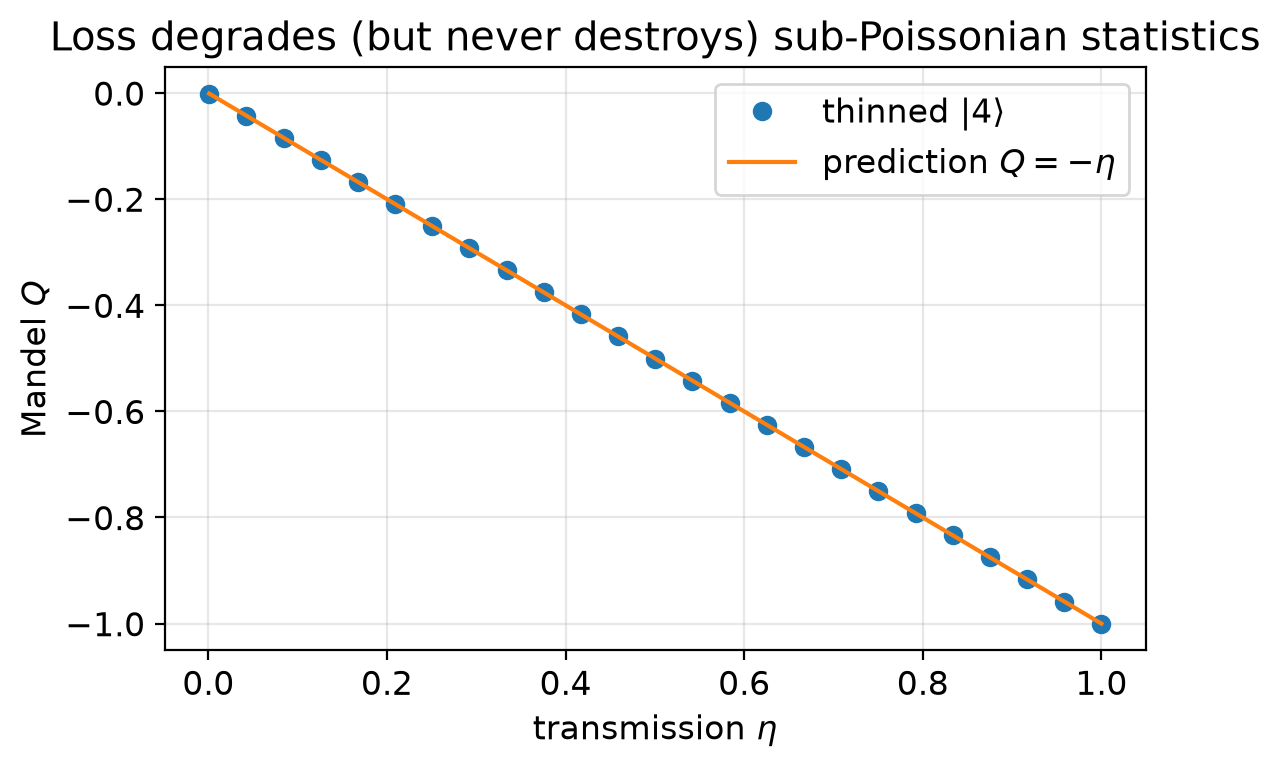

In [17]:
# Solution - Stretch exercise
from scipy.stats import binom

def thin(P: np.ndarray, eta: float) -> np.ndarray:
    """Binomial thinning of a photon number distribution with transmission eta."""
    N_dim = len(P)
    P_out = np.zeros(N_dim)
    for n in range(N_dim):
        if P[n] > 0:
            m = np.arange(n + 1)
            P_out[:n + 1] += P[n] * binom.pmf(m, n, eta)
    return P_out

P4 = photon_number_distribution(qutip.fock(N, 4))
eta_axis = np.linspace(0.001, 1, 25)
Q_vals = []
for eta in eta_axis:
    Pt = thin(P4, eta)
    n = np.arange(N)
    mean = np.sum(n * Pt)
    var = np.sum(n**2 * Pt) - mean**2
    Q_vals.append((var - mean) / mean)

plt.plot(eta_axis, Q_vals, "o", label="thinned $|4\\rangle$")
plt.plot(eta_axis, -eta_axis, "-", label=r"prediction $Q = -\eta$")
plt.xlabel(r"transmission $\eta$"); plt.ylabel("Mandel $Q$")
plt.title("Loss degrades (but never destroys) sub-Poissonian statistics")
plt.legend(); plt.tight_layout(); plt.show()

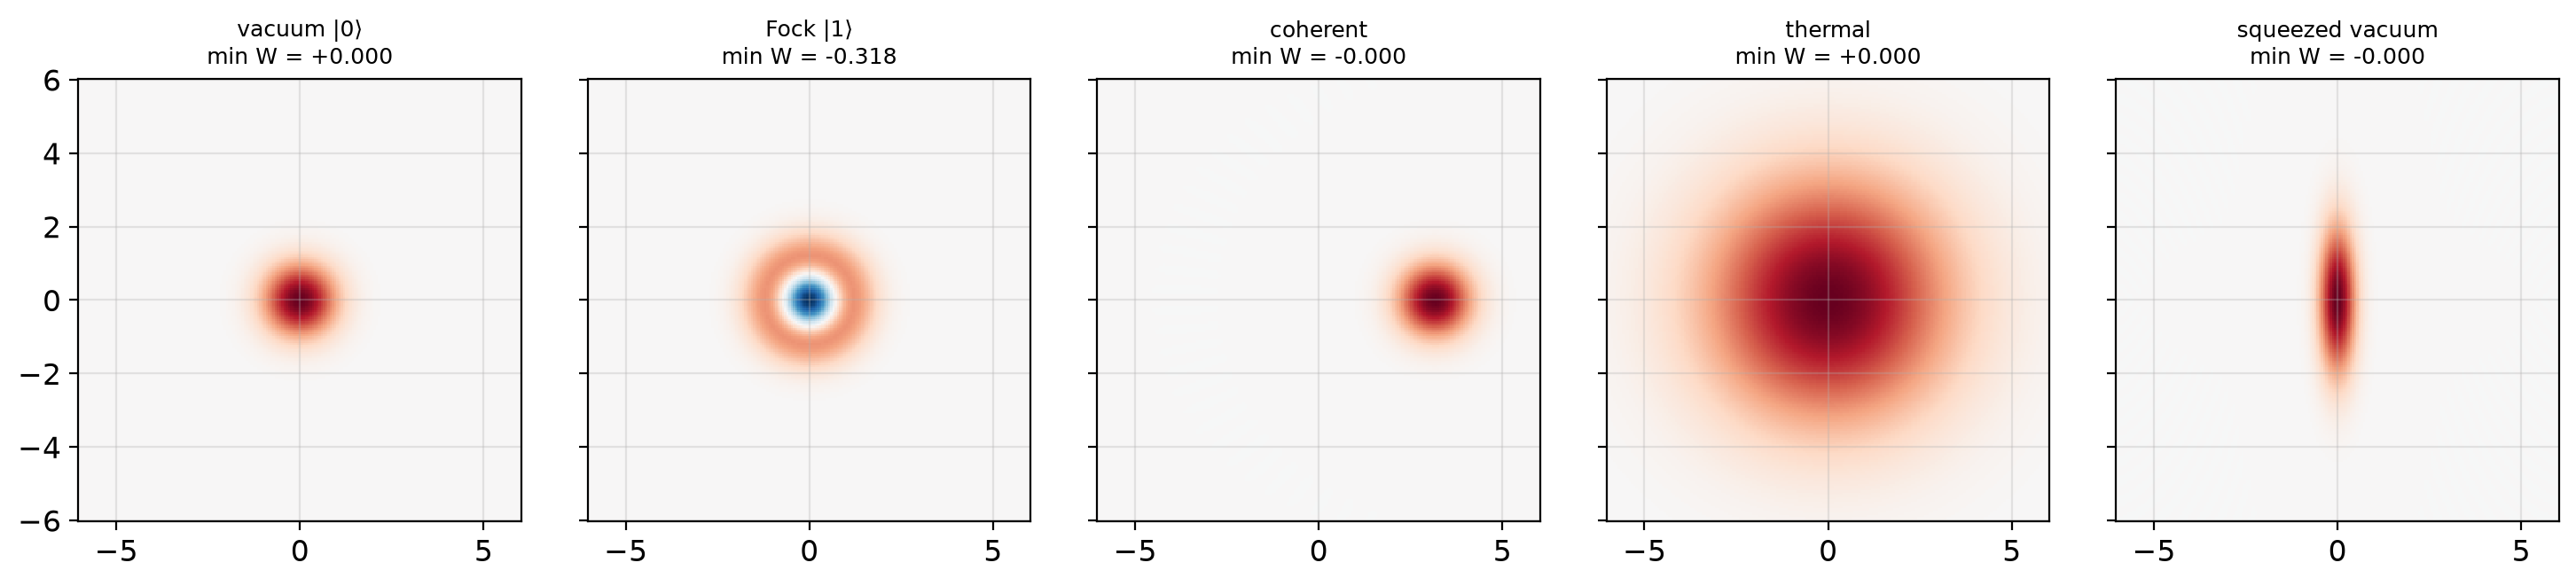

Wigner-negative (hence non-classical): only |1> here.
Q < 0: only |1> as well - but squeezed vacuum is non-classical too
(squeezed quadrature noise), and BOTH its Q and min(W) miss it. 
No single witness catches all quantum states.

state                  dX     dP   (vacuum: 0.707)
vacuum $|0\rangle$  0.707  0.707
Fock $|1\rangle$    1.225  1.225
coherent            0.707  0.707
thermal             2.345  2.345
squeezed vacuum     0.351  1.424  <- squeezed!


In [18]:
# Solution - Exercise 4
xvec = np.linspace(-6, 6, 201)
states_4 = [(r"vacuum $|0\rangle$", qutip.fock(N, 0)),
            (r"Fock $|1\rangle$", qutip.fock(N, 1)),
            ("coherent", psi_coh),
            ("thermal", rho_th),
            ("squeezed vacuum", qutip.squeeze(N, 0.7) * qutip.fock(N, 0))]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.1), sharey=True)
for ax, (label, st) in zip(axes, states_4):
    W = qutip.wigner(st, xvec, xvec)
    vmax = np.abs(W).max()
    ax.pcolormesh(xvec, xvec, W, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{label}\nmin W = {W.min():+.3f}", fontsize=9)
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

print("Wigner-negative (hence non-classical): only |1> here.")
print("Q < 0: only |1> as well - but squeezed vacuum is non-classical too")
print("(squeezed quadrature noise), and BOTH its Q and min(W) miss it. ")
print("No single witness catches all quantum states.")

# ...and the quadrature-noise check: who is actually squeezed?
x_op, p_op = qutip.position(N), qutip.momentum(N)
print(f"\n{'state':<18}{'dX':>7}{'dP':>7}   (vacuum: 0.707)")
for label, st in states_4:
    dx = np.sqrt(qutip.variance(x_op, st))
    dp = np.sqrt(qutip.variance(p_op, st))
    tag = "  <- squeezed!" if min(dx, dp) < 1 / np.sqrt(2) - 1e-6 else ""
    print(f"{label:<18}{dx:>7.3f}{dp:>7.3f}{tag}")
# Only the squeezed vacuum beats the vacuum level. The Fock state |1> is
# Wigner-negative yet NOT squeezed - two orthogonal kinds of quantumness.

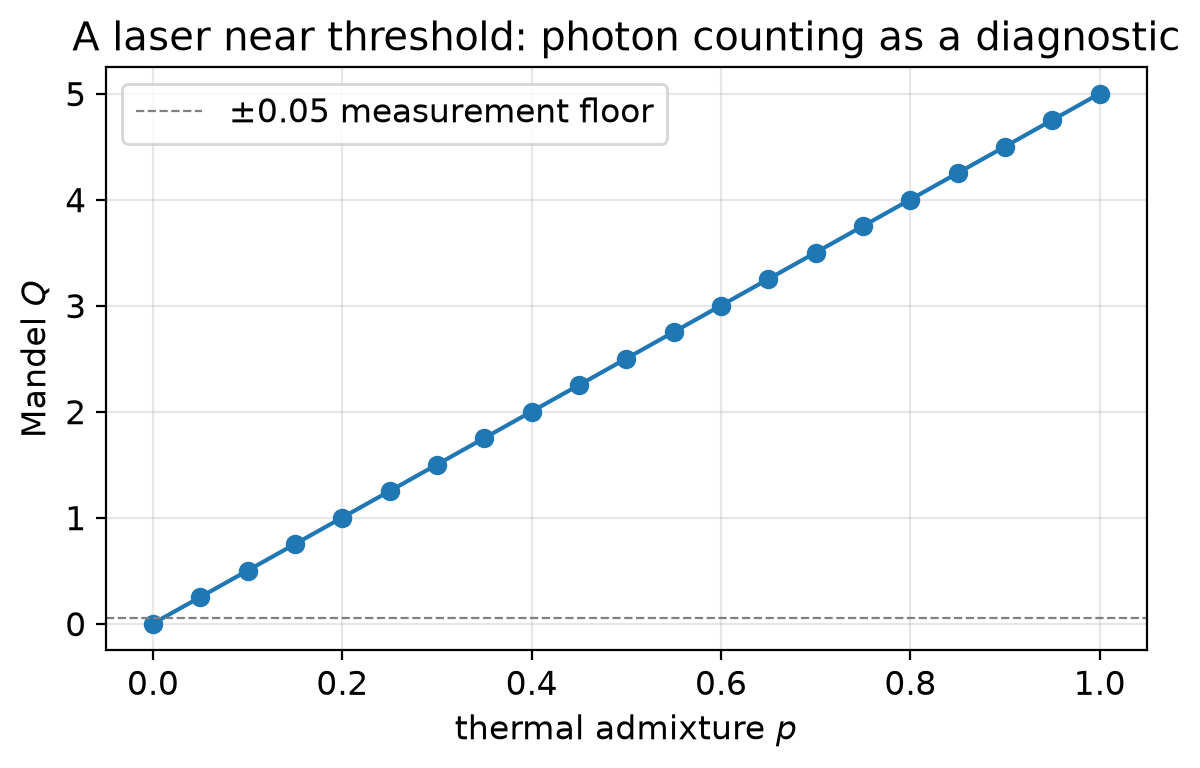

Q exceeds 0.05 already at p ≈ 0.05: photon statistics detect a few-percent thermal admixture.


In [19]:
# Solution - Exercise 5
p_values = np.linspace(0, 1, 21)
rho_coh = qutip.ket2dm(psi_coh)
Q_mix = [mandel_Q((1 - p) * rho_coh + p * rho_th) for p in p_values]

plt.plot(p_values, Q_mix, "o-")
plt.axhline(0.05, color="gray", ls="--", lw=0.8, label="±0.05 measurement floor")
plt.xlabel("thermal admixture $p$")
plt.ylabel("Mandel $Q$")
plt.title("A laser near threshold: photon counting as a diagnostic")
plt.legend(); plt.tight_layout(); plt.show()

detectable = p_values[np.array(Q_mix) > 0.05]
print(f"Q exceeds 0.05 already at p ≈ {detectable[0]:.2f}: "
      "photon statistics detect a few-percent thermal admixture.")

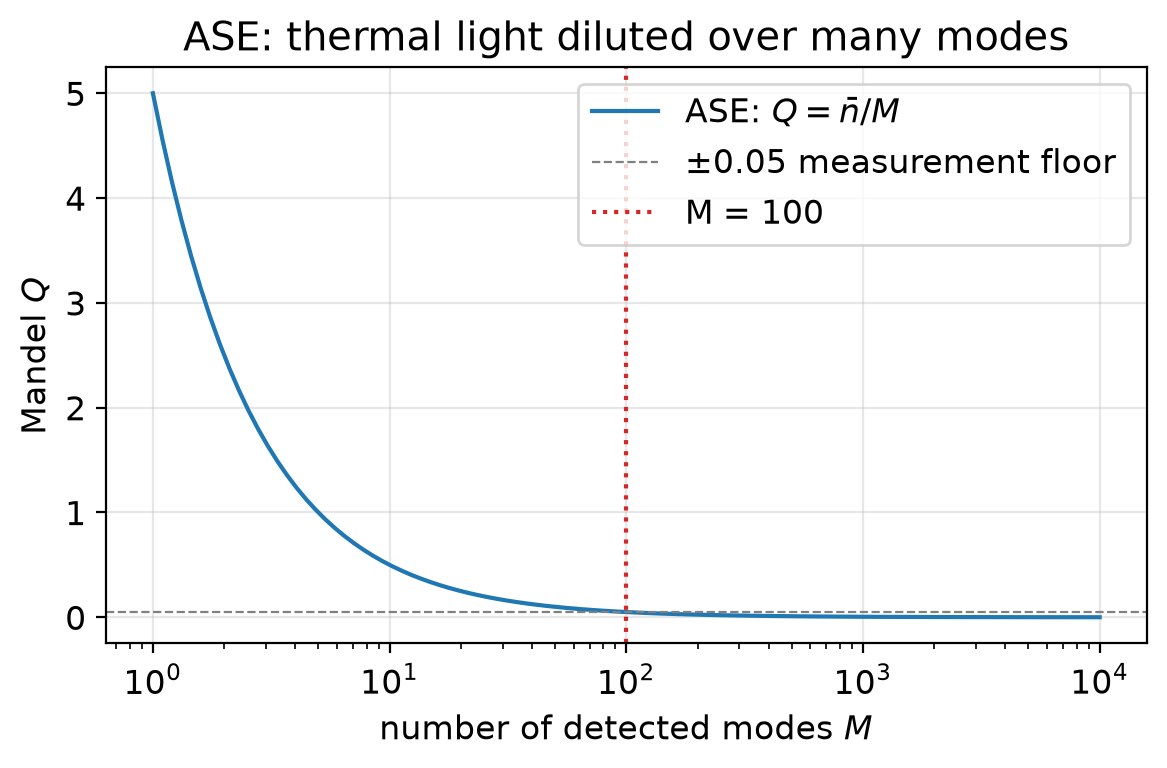

Q stays above 0.05 only for M < 100 modes.
An unfiltered EDFA emits ASE over ~THz bandwidth x 2 polarizations:
M ~ 1e6-1e7 detected modes, Q ~ 1e-6 - counting statistics cannot
tell it from a laser. Filter down toward a single mode and ASE is
as thermal as a lamp: g2(0) = 2, which is exactly what Tuesday's
coincidence measurement can see even through heavy loss.


In [20]:
# Solution - Exercise 5, part 4 (ASE)
nbar = 5.0
M_ax = np.logspace(0, 4, 100)          # number of detected modes

plt.semilogx(M_ax, nbar / M_ax, label=r"ASE: $Q = \bar{n}/M$")
plt.axhline(0.05, color="gray", ls="--", lw=0.8,
            label=r"$\pm 0.05$ measurement floor")
plt.axvline(nbar / 0.05, color="tab:red", ls=":",
            label=f"M = {nbar/0.05:.0f}")
plt.xlabel("number of detected modes $M$")
plt.ylabel("Mandel $Q$")
plt.title("ASE: thermal light diluted over many modes")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Q stays above 0.05 only for M < {nbar/0.05:.0f} modes.")
print("An unfiltered EDFA emits ASE over ~THz bandwidth x 2 polarizations:")
print("M ~ 1e6-1e7 detected modes, Q ~ 1e-6 - counting statistics cannot")
print("tell it from a laser. Filter down toward a single mode and ASE is")
print("as thermal as a lamp: g2(0) = 2, which is exactly what Tuesday's")
print("coincidence measurement can see even through heavy loss.")